# Week 6 – Day 3

# Time Series Decomposition

**Name:** Mohit Singh

## Objective

The objective of this notebook is to decompose the monthly closing prices of Reliance Industries into four components:

- Observed Series
- Trend
- Seasonal Component
- Residual Component

Time series decomposition helps us understand the underlying structure of the data before building forecasting models.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Import seasonal decomposition function
from statsmodels.tsa.seasonal import seasonal_decompose

## 1. Download Historical Stock Data

In [2]:
# Download Reliance stock data
reliance = yf.download(
    "RELIANCE.NS",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Display the first five rows
reliance.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216064,680.008728,670.390410,675.956548,14004468
2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316
2020-01-03,684.484070,686.487896,678.183128,682.636062,20984698
2020-01-06,668.609375,680.365106,667.050830,676.847322,24519177
2020-01-07,678.895691,683.304098,673.952887,676.401995,16683622


## 2. Convert the Index to Datetime

In [3]:
# Ensure the index is in datetime format
reliance.index = pd.to_datetime(reliance.index)

# Verify the index type
print(type(reliance.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


## 3. Resample Daily Data to Monthly Frequency

In [4]:
# Select the last closing price of each month
monthly_close = reliance["Close"].resample("ME").last()

# Display the first five monthly observations
monthly_close.head()

Ticker,RELIANCE.NS
Date,
2020-01-31,628.599609
2020-02-29,591.640259
2020-03-31,495.946472
2020-04-30,652.801331
2020-05-31,658.270081


## 4. Apply Seasonal Decomposition

In [5]:
# Perform additive decomposition
decomposition = seasonal_decompose(
    monthly_close,
    model="additive",
    period=12
)

## 5. Plot Decomposition

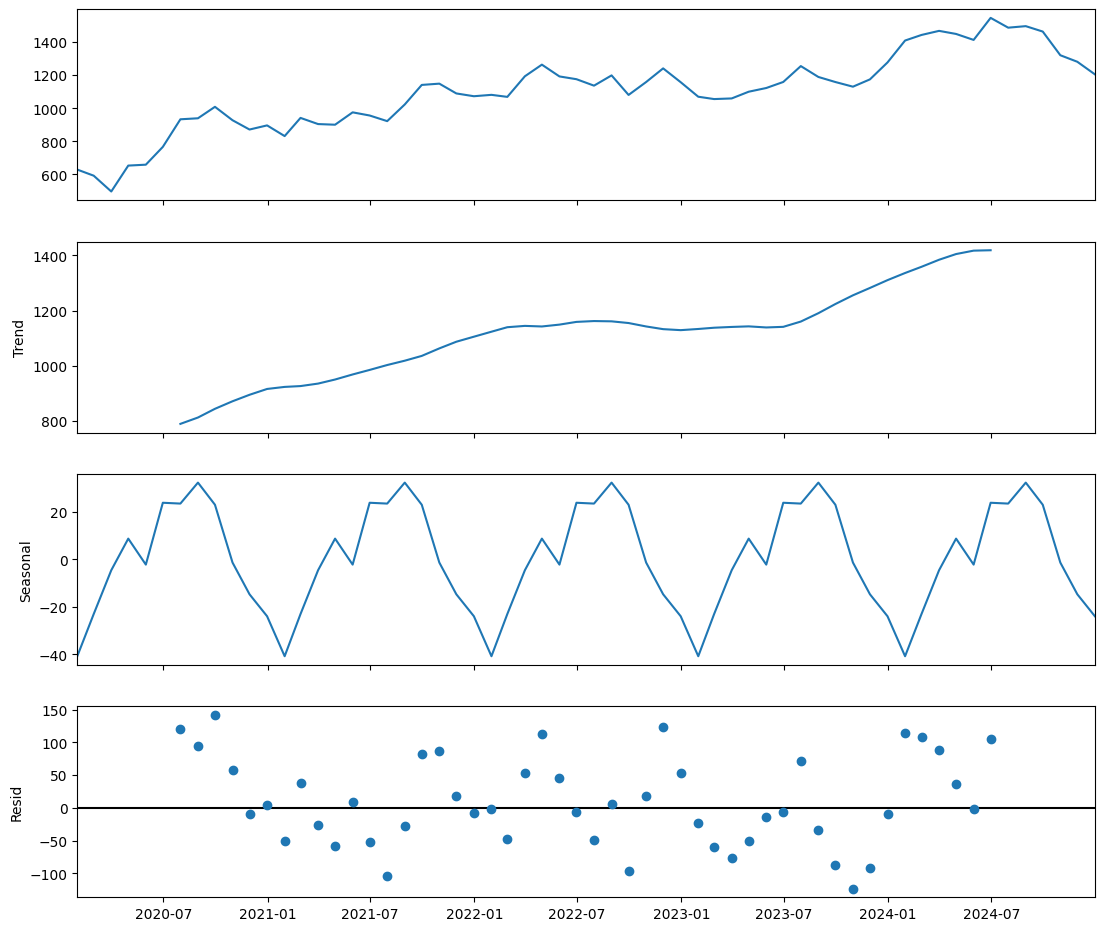

In [6]:
# Plot all four components
fig = decomposition.plot()

# Adjust figure size
fig.set_size_inches(12, 10)

plt.savefig(
    "../images/seasonal_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Understanding the Four Components

### 1. Observed

The original monthly closing price series.



### 2. Trend

Represents the long-term direction of stock prices.

A rising trend indicates long-term growth.



### 3. Seasonal

Represents repeating patterns occurring every year.

Financial data often has weak seasonality compared to sales or weather data.



### 4. Residual

Represents random fluctuations that cannot be explained by the trend or seasonal component.

## 6. Inspect Individual Components

In [ ]:
# Display the first few values of each component

print("Trend")
print(decomposition.trend.head())

print("\nSeasonal")
print(decomposition.seasonal.head())

print("\nResidual")
print(decomposition.resid.head())

Trend
Date
2020-01-31   NaN
2020-02-29   NaN
2020-03-31   NaN
2020-04-30   NaN
2020-05-31   NaN
Freq: ME, Name: trend, dtype: float64

Seasonal
Date
2020-01-31   -40.820822
2020-02-29   -23.066635
2020-03-31    -4.636734
2020-04-30     8.663250
2020-05-31    -2.272380
Freq: ME, Name: seasonal, dtype: float64

Residual
Date
2020-01-31   NaN
2020-02-29   NaN
2020-03-31   NaN
2020-04-30   NaN
2020-05-31   NaN
Freq: ME, Name: resid, dtype: float64


## Interpretation

### Trend

The trend component shows the long-term movement in Reliance's stock price.



### Seasonal Component

The seasonal component represents recurring monthly patterns. Since stock prices are heavily influenced by market events rather than fixed seasonal cycles, this component may appear relatively small.



### Residual Component

The residual captures irregular movements that are not explained by either the trend or seasonal pattern. These fluctuations are often caused by unexpected market news or economic events.

# Conclusion

Seasonal decomposition separated the monthly closing prices of Reliance Industries into four components: observed, trend, seasonal, and residual.

The trend component revealed the long-term direction of the stock price, while the seasonal component showed whether any recurring yearly pattern existed. The residual component represented random movements not explained by the other components.

This decomposition helps in understanding the underlying structure of the time series and is a useful preprocessing step before applying forecasting models such as Holt-Winters or SARIMA.